<a href="https://colab.research.google.com/github/maameakos/Project-4-Consumer-Spending/blob/main/Consumer_Spending.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Dependencies
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, mean_squared_error, r2_score

In [ ]:
# Print current working directory
print("Current Working Directory:", os.getcwd())

# Set the file path to the Downloads directory (Mac)
downloads_path = Path("customer_data.csv")

# Read in the CSV file as a Pandas DataFrame
df_customer_data = pd.read_csv(downloads_path)

# Review the DataFrame
print(df_customer_data.head())

Current Working Directory: /content
                 name  age  gender    education  income   country  \
0  Teresa Williams MD   42  Female  High School   53936  Slovenia   
1     Christine Myers   49  Female       Master   82468     Aruba   
2       Dwayne Moreno   55    Male     Bachelor   56941    Cyprus   
3          Amy Norton   24  Female     Bachelor   60651     Palau   
4         Tonya Adams   64    Male       Master   81884    Zambia   

   purchase_frequency   spending  
0                 0.9  13227.120  
1                 0.6  12674.040  
2                 0.3   5354.115  
3                 0.2   2606.510  
4                 0.9  18984.780  


In [ ]:
# Display the number of rows in the DataFrame
print("Rows in DataFrame: ", len(df_customer_data))

# Display the first 10 rows of the DataFrame
df_customer_data.head(10)

Rows in DataFrame:  1000


,name,age,gender,education,income,country,purchase_frequency,spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780
5,Charles Smith,24,Female,PhD,61444,Libyan Arab Jamahiriya,1.0,18072.200
6,Misty Moody,58,Male,PhD,78024,Italy,0.9,21511.080
7,Brian Kent,34,Male,High School,32225,Pakistan,0.7,6727.875
8,Stacie Ray,63,Male,PhD,63664,Venezuela,0.4,9273.280
9,Brian Townsend,64,Female,High School,45043,San Marino,1.0,16252.150


In [ ]:
# Delete columns by name with df.drop()
df_customer_data = df_customer_data.drop(["name", "gender"],
axis = 1)
df_customer_data.head()

,age,education,income,country,purchase_frequency,spending
0,42,High School,53936,Slovenia,0.9,13227.120
1,49,Master,82468,Aruba,0.6,12674.040
2,55,Bachelor,56941,Cyprus,0.3,5354.115
3,24,Bachelor,60651,Palau,0.2,2606.510
4,64,Master,81884,Zambia,0.9,18984.780


In [ ]:
# Determine the number of unique values in each column.
df_customer_data.nunique()

,0
age,48
education,4
income,997
country,239
purchase_frequency,10
spending,1000


In [ ]:
# Generate summary statistics
df_customer_data.describe()

,age,income,purchase_frequency,spending
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.754000,59277.852000,0.554600,9613.296835
std,13.778582,23258.377128,0.284675,5484.707210
min,18.000000,20031.000000,0.100000,611.985000
25%,30.000000,38825.500000,0.300000,5020.425000
50%,42.000000,58972.000000,0.600000,9430.395000
75%,54.000000,79114.000000,0.800000,13645.507500
max,65.000000,99780.000000,1.000000,25546.500000


In [ ]:
# Collect a list of all the unique values in "education",
df_customer_data["education"].unique()

array(['High School', 'Master', 'Bachelor', 'PhD'], dtype=object)

In [ ]:
# Reference multiple columns within a DataFrame
df_customer_data[["education", "income"]].head()

,education,income
0,High School,53936
1,Master,82468
2,Bachelor,56941
3,Bachelor,60651
4,Master,81884


In [ ]:
# Show the mean method of averages for AGE
average = df_customer_data["age"].mean()
"The average is" + str(average)

'The average is41.754'

In [ ]:
# Caculate the annual spending of each customer
spending_count = (df_customer_data["spending"].unique)
print(spending_count)

<bound method Series.unique of 0      13227.120
1      12674.040
2       5354.115
3       2606.510
4      18984.780
         ...    
995    17435.950
996    11662.830
997     7196.160
998    13939.520
999     8312.800
Name: spending, Length: 1000, dtype: float64>


In [ ]:
# Drop all rows with missing information
df_customer_data = df_customer_data.dropna(how = 'any')

In [ ]:
# Verify dropped rows
df_customer_data.count()

,0
age,1000
education,1000
income,1000
country,1000
purchase_frequency,1000
spending,1000


In [ ]:
# Display an overview of the purchase_frequency column
df_customer_data["purchase_frequency"].value_counts()

,count
purchase_frequency,
0.7,119
0.6,109
0.1,109
1.0,103
0.5,101
0.4,98
0.8,97
0.3,96
0.9,89


In [ ]:
# Drop the non-beneficial ID columns, 'education', 'country'
df_customer_data.drop(columns = ["education", "country"],inplace =True)
df_customer_data.head()
#Convert the column to float
df_customer_data = df_customer_data.astype(float)

#Print the DataFrame
print(df_customer_data)

      age   income  purchase_frequency   spending
0    42.0  53936.0                 0.9  13227.120
1    49.0  82468.0                 0.6  12674.040
2    55.0  56941.0                 0.3   5354.115
3    24.0  60651.0                 0.2   2606.510
4    64.0  81884.0                 0.9  18984.780
..    ...      ...                 ...        ...
995  42.0  98170.0                 0.7  17435.950
996  39.0  59174.0                 0.9  11662.830
997  50.0  59808.0                 0.4   7196.160
998  50.0  58272.0                 0.7  13939.520
999  38.0  32512.0                 0.5   8312.800

[1000 rows x 4 columns]


In [ ]:
# Define features set
X = df_customer_data.copy()
X.drop("purchase_frequency", axis = 1, inplace = True)
X.head()

,age,income,spending
0,42.0,53936.0,13227.120
1,49.0,82468.0,12674.040
2,55.0,56941.0,5354.115
3,24.0,60651.0,2606.510
4,64.0,81884.0,18984.780


In [ ]:
# Define target vector
y = df_customer_data["purchase_frequency"].values.reshape(-1, 1)
y[:10]

array([[0.9],
       [0.6],
       [0.3],
       [0.2],
       [0.9],
       [1. ],
       [0.9],
       [0.7],
       [0.4],
       [1. ]])

In [ ]:
# Splitting into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state =75)

In [ ]:
# Creating StandardScaler instance
scaler = StandardScaler()

In [ ]:
# fit the StandardScaler with the training data
X_scaler = scaler.fit(X_train)

In [ ]:
# Get the target variables
target = df_customer_data["purchase_frequency"]

In [ ]:
# scale the training data
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

In [ ]:
# Create the random forest classifier instance
rf_model = RandomForestRegressor(n_estimators=500, random_state = 75)

In [ ]:
X_train_scaled

array([[-1.2586631 ,  0.89262813,  0.60029282],
       [ 0.03104862, -1.11530498,  0.70167941],
       [ 0.67590447,  0.83379554,  0.9453494 ],
       ...,
       [-0.75710854,  0.90410872,  1.04785089],
       [ 1.53571228,  0.92312751, -0.48754379],
       [-1.4019644 , -0.11068858, -0.11652045]])

In [ ]:
# Fit the model
rf_model = rf_model.fit(X_train_scaled, y_train.ravel())

In [ ]:
# Making predictions using the testing data
predictions = rf_model.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [ ]:
# highest_education = data.groupby('custom_id')['education_level'].max ()


print(predictions)

[0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991
 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.991 0.

In [ ]:

# Predictions
y_pred_train = rf_model.predict(X_train_scaled)
y_pred_test = rf_model.predict(X_test_scaled)

# Calculate Metrics
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Summary of Metrics
metrics_summary = {
    'Metric': ['MSE', 'RMSE', 'R²'],
    'Train': [train_mse, train_rmse, train_r2],
    'Test': [test_mse, test_rmse, test_r2]
}

metrics_df = pd.DataFrame(metrics_summary)
print(metrics_df)

  Metric     Train      Test
0    MSE  0.001453  0.010891
1   RMSE  0.038113  0.104362
2     R²  0.982005  0.866624


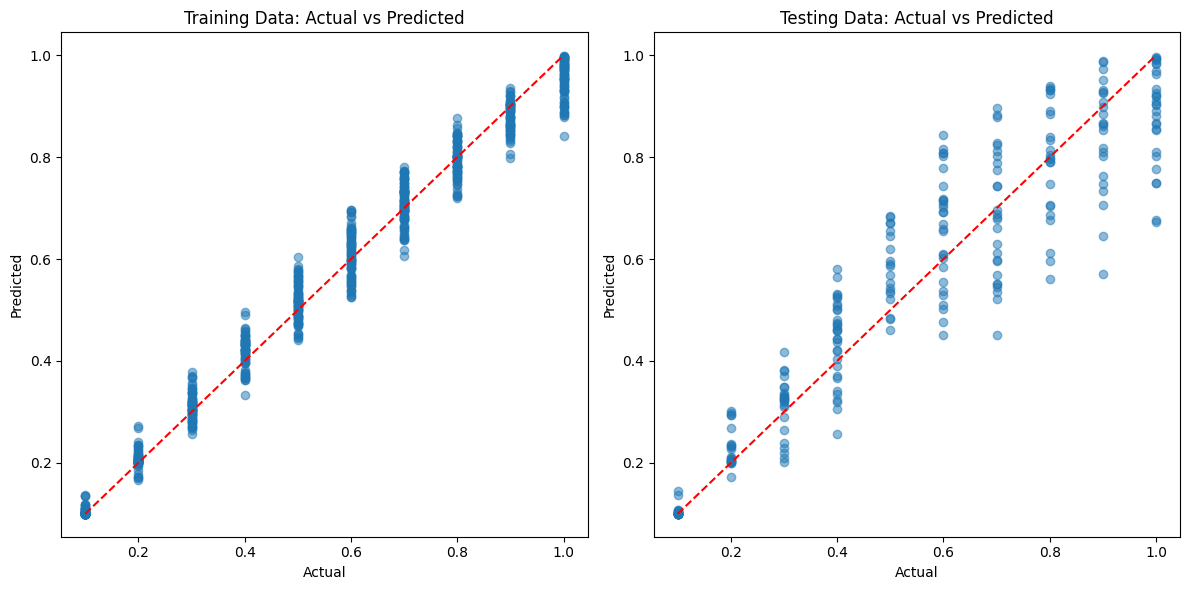

In [ ]:
plt.figure(figsize=(12, 6))

# Training Data
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Training Data: Actual vs Predicted')

# Testing Data
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Testing Data: Actual vs Predicted')

plt.tight_layout()
plt.show()